In [1]:
from Python_Libraries import *

In [2]:
final_df = pd.read_csv('ecommerce_merged_dataset_for_EDA.csv')
final_df.head()

,order_id,customer_id,order_status,payment_type,order_purchase_timestamp,order_approved_at,order_delivered_shipping_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code,...,product_weight_g,brand,cost_price,selling_price,stock_availability,review_id,review_score,review_date,geolocation_state,region
0,O00001,C60210,delivered,Net Banking,11/4/2024,11/4/2024,12/1/2024,3/4/2025,1/3/2025,413514,...,1325.0,Generic Indian,5330.0,7020.0,In Stock,R89199,1.0,4/5/2025,Maharashtra,West
1,O00002,C01893,delivered,Net Banking,9/1/2023,9/1/2023,10/1/2023,10/5/2023,10/31/2023,523230,...,24700.0,Generic Indian,6190.0,7590.0,In Stock,R37310,5.0,5/13/2023,Andhra Pradesh,South
2,O00002,C01893,delivered,Net Banking,9/1/2023,9/1/2023,10/1/2023,10/5/2023,10/31/2023,523230,...,400.0,Generic Indian,11720.0,14360.0,In Stock,R37310,5.0,5/13/2023,Andhra Pradesh,South
3,O00003,C19454,cancelled,UPI,8/6/2021,NaN,NaN,NaN,NaN,532186,...,5400.0,Generic Indian,1300.0,1530.0,In Stock,R03279,4.0,6/11/2021,Andhra Pradesh,South
4,O00003,C19454,cancelled,UPI,8/6/2021,NaN,NaN,NaN,NaN,532186,...,650.0,Generic Indian,1300.0,1560.0,In Stock,R03279,4.0,6/11/2021,Andhra Pradesh,South


In [3]:
# Checking Data type:
print(final_df.dtypes)

order_id                          object
customer_id                       object
order_status                      object
payment_type                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_shipping_date     object
order_delivered_customer_date     object
order_estimated_delivery_date     object
customer_zip_code                  int64
gender                            object
age_group                         object
customer_segment                  object
order_item_id                     object
quantity                         float64
product_id                        object
unit_price                       float64
discount(%)                      float64
shipping_cost                    float64
Category_name                     object
sub_category_name                 object
product_weight_g                 float64
brand                             object
cost_price                       float64
selling_price   

In [4]:
# Converting Date columns in to Date format
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_shipping_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_date'
]

for col in date_cols:
    final_df[col] = pd.to_datetime(final_df[col])

# Converting category columns into category
cat_cols = [
    'order_status',
    'payment_type',
    'customer_zip_code',
    'gender',
    'age_group',
    'customer_segment',
    'Category_name',
    'sub_category_name',
    'brand',
    'stock_availability',
    'geolocation_state',
    'region'
]

for col in cat_cols:
    final_df[col] = final_df[col].astype('category')


In [5]:
# Features creation

# Delivery Days
final_df['delivery_days'] = (
    final_df['order_delivered_customer_date']
    - final_df['order_purchase_timestamp']
).dt.days

# Delivery Delay Days
final_df['delivery_delay_days'] = (
     final_df['order_delivered_customer_date']
    - final_df['order_estimated_delivery_date']
).dt.days

# Discount Amount
final_df['discount_amount'] = (
    final_df['selling_price'] * final_df['discount(%)'] / 100
)

# Profit Margin
final_df['profit_margin'] = (
    final_df['selling_price']
    - final_df['cost_price']
    - final_df['shipping_cost']
)

# Purchase Month
final_df['purchase_month'] = (
    final_df['order_purchase_timestamp']
    .dt.month_name()
)

# Purchase Year
final_df['purchase_year'] = (
    final_df['order_purchase_timestamp']
    .dt.year
)

# Purchase Weekday
final_df['purchase_weekday'] = (
    final_df['order_purchase_timestamp']
    .dt.day_name()
)

### Creating Price and Discount Bands

These bands are created on `final_df` before `delivered_df` is generated, ensuring they are available for subsequent analysis.

In [6]:
# ============================================
# Creating Price Bands
# ============================================

price_bins = [
    0,
    5000,
    15000,
    30000,
    float('inf')
]

price_labels = [
    '<5000',
    '5000-15000',
    '15000-30000',
    '30000+'
]

final_df['price_band'] = pd.cut(
    final_df['selling_price'],
    bins=price_bins,
    labels=price_labels
)

In [7]:
# ============================================
# Creating Discount Bands
# ============================================

discount_bins = [-1, 0, 10, 25, 50, 100]

discount_labels = [
    'No Discount',
    'Low (1-10%)',
    'Medium (11-25%)',
    'High (26-50%)',
    'Very High (50%+)'
]

final_df['discount_band'] = pd.cut(
    final_df['discount(%)'],
    bins=discount_bins,
    labels=discount_labels
)

In [8]:
# ============================================
# Delivered Orders Dataset
# ============================================

delivered_df = final_df[
    final_df['order_status'] == 'delivered'
].copy()

In [9]:
# ============================================
# Repeat Purchase Flag
# ============================================

delivered_df['repeat_purchase_flag'] = (
    delivered_df.groupby('customer_id')['order_id']
    .transform('nunique') > 1
).astype(int)

In [10]:
# ============================================
# Purchase Sequence
# ============================================

delivered_df = delivered_df.sort_values(
    ['customer_id', 'order_purchase_timestamp']
)

delivered_df['purchase_sequence'] = (
    delivered_df.groupby('customer_id')
    .cumcount() + 1
)



In [11]:
# ============================================
# Creating Price Bands
# ============================================

price_bins = [
    0,
    5000,
    15000,
    30000,
    float('inf')
]

price_labels = [
    '<5000',
    '5000-15000',
    '15000-30000',
    '30000+'
]

final_df['price_band'] = pd.cut(
    final_df['selling_price'],
    bins=price_bins,
    labels=price_labels
)

In [12]:
# ============================================
# Creating Discount Bands
# ============================================

discount_bins = [-1, 0, 10, 25, 50, 100]

discount_labels = [
    'No Discount',
    'Low (1-10%)',
    'Medium (11-25%)',
    'High (26-50%)',
    'Very High (50%+)'
]

final_df['discount_band'] = pd.cut(
    final_df['discount(%)'],
    bins=discount_bins,
    labels=discount_labels
)

# Business Objective 1
## Analysis of Factors Influencing First Purchase Behavior among New Customers

# 1. Which product categories and brands attract the highest number of first-time purchases among new customers?

(47774, 42)
Category_name
fashion_bags_accessories    1312
perfumery                   1383
watches_gifts               1409
stationery                  1454
toys                        1610
auto                        1669
housewares                  2521
health_beauty               2607
sports_leisure              3075
bed_bath_table              3247
Name: count, dtype: int64


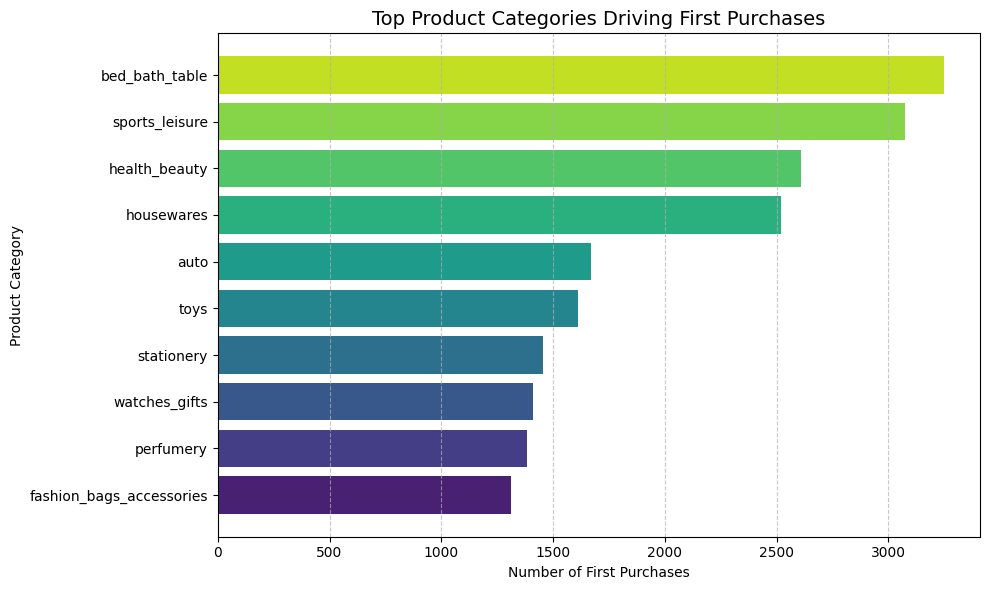

In [13]:
# ============================================
# First Purchase Dataset
# ============================================

first_purchase_df = delivered_df[
    delivered_df['purchase_sequence'] == 1
].copy()

print(first_purchase_df.shape)

# ============================================
# Top Categories for First Purchases
# ============================================

top_categories = (
    first_purchase_df['Category_name']
    .value_counts()
    .head(10)
    .sort_values()
)

print(top_categories)

# Plot
plt.figure(figsize=(10,6))

plt.barh(top_categories.index.astype(str),
                top_categories.values,
                color=sns.color_palette('viridis', len(top_categories)))

plt.title('Top Product Categories Driving First Purchases', fontsize=14)
plt.xlabel('Number of First Purchases')
plt.ylabel('Product Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** 'bed_bath_table', 'sports_leisure', and 'health_beauty' are the most popular product types for first purchases. This shows that new customers often buy practical items for their home and personal care first.
*   **Insight:** New buyers are often looking for things they need right away or items to improve their everyday life.
*   **Solution:** We should focus our ads and first-time offers on these popular and useful categories. We also need to make it easy for new customers to find and buy these products on our website.

Category_name
security_and_services                     2
cds_dvds_musicals                         2
home_comfort_2                            3
furniture_mattress_and_upholstery         4
diapers_and_hygiene                       7
fashion_childrens_clothes                 9
small_appliances_home_oven_and_coffee    10
flowers                                  11
tablets_printing_image                   11
la_cuisine                               13
Name: count, dtype: int64


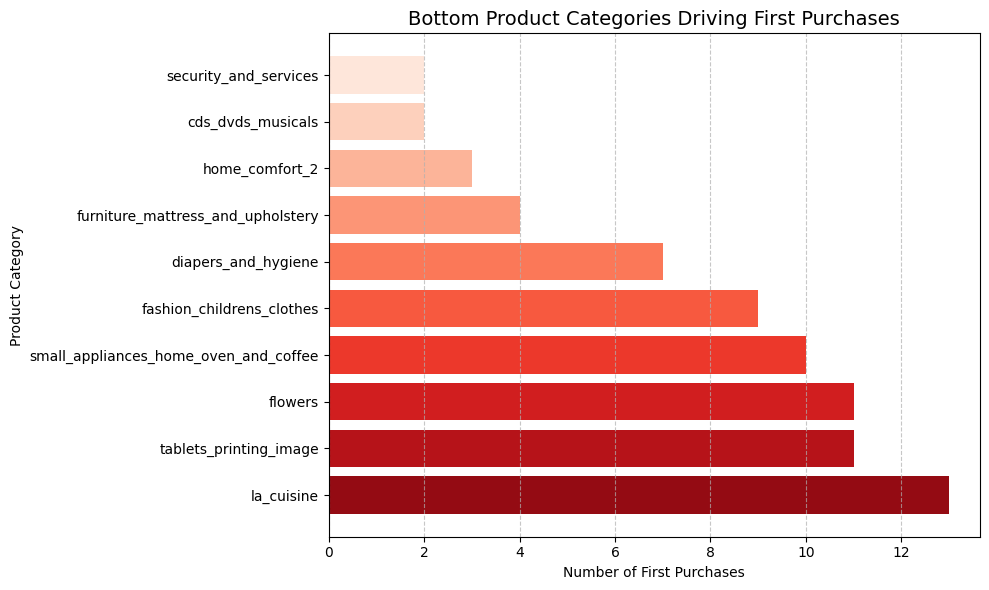

In [14]:
# ============================================
# Bottom Categories for First Purchases
# ============================================

bottom_categories = (
    first_purchase_df['Category_name']
    .value_counts()
    .tail(10)
    .sort_values())

print(bottom_categories)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    bottom_categories.index.astype(str),
    bottom_categories.values,
    color=sns.color_palette('Reds', len(bottom_categories)))

plt.title('Bottom Product Categories Driving First Purchases',fontsize=14)

plt.xlabel('Number of First Purchases')
plt.ylabel('Product Category')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

brand
Minda                  349
Amaron                 363
Bosch India            363
Drools                 365
Himalaya Pet Care      427
Camel                  554
Navneet                573
Classmate              578
Generic Global        3087
Generic Indian       18073
Name: count, dtype: int64


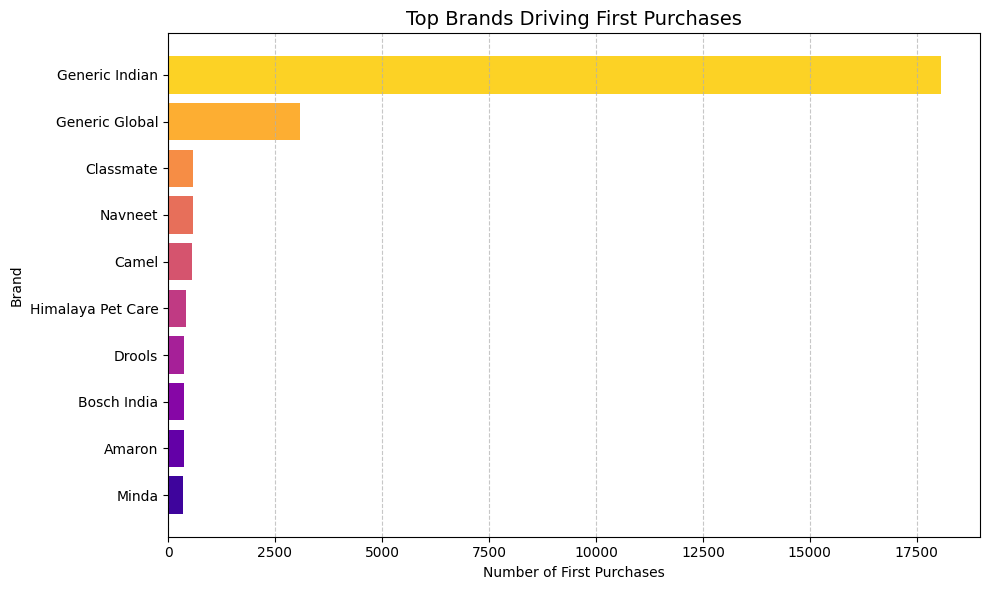

In [15]:
# ============================================
# Top Brands for First Purchases
# ============================================

top_brands = (
    first_purchase_df['brand']
    .value_counts()
    .head(10)
    .sort_values()
)

print(top_brands)

# Plot

plt.figure(figsize=(10,6))

plt.barh(top_brands.index.astype(str),
                top_brands.values,
                color=sns.color_palette('plasma', len(top_brands)))

plt.title('Top Brands Driving First Purchases',fontsize=14)
plt.xlabel('Number of First Purchases')
plt.ylabel('Brand')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** 'Generic Indian' and 'Generic Global' brands are bought most often by new customers, followed by well-known education and pet care brands.
*   **Insight:** New customers often start with familiar, basic, or generic items before checking out more specialized brands.
*   **Solution:** We should use the popularity of generic brands to attract new customers, as they are a good starting point. Then, we can use cross-promotions to introduce these customers to more valuable, specialized brands after their first purchase, helping them become more engaged.

# 2. How do pricing and discount ranges influence first-purchase behavior among new customers?

price_band
<5000          14893
5000-15000     13735
15000-30000     1580
30000+          1517
Name: count, dtype: int64


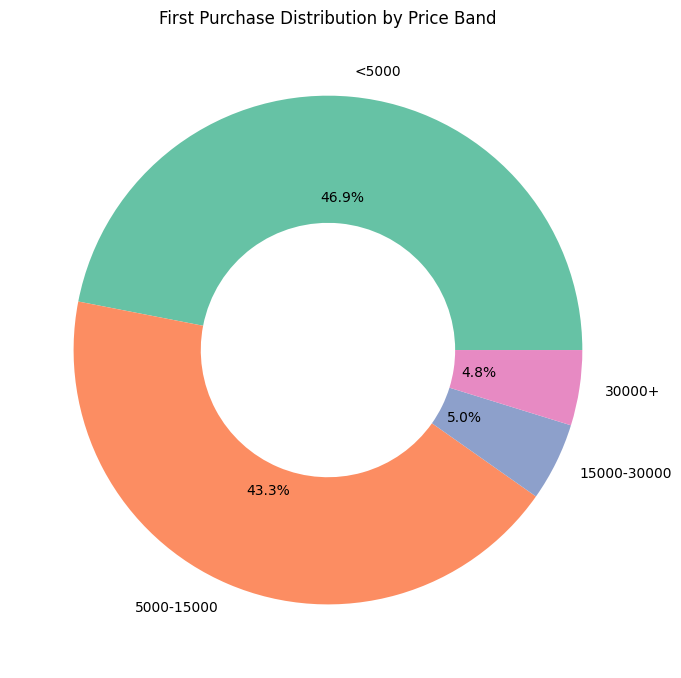

In [16]:
# ============================================
# First Purchase Share by Price Band
# ============================================

price_distribution = (
    first_purchase_df['price_band']
    .value_counts()
)

print(price_distribution)

# Plot

plt.figure(figsize=(7,7))

plt.pie(
    price_distribution.values,
    labels=price_distribution.index.astype(str),
    autopct='%1.1f%%',
    wedgeprops={'width':0.5},
    colors=sns.color_palette('Set2')
)

plt.title('First Purchase Distribution by Price Band')
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** Most first purchases (about 78%) are for items priced under '5000' and '5000-15000'.
*   **Insight:** New customers are very careful about price and prefer items that are low to mid-range in cost for their first purchase.
*   **Solution:** We should create special offers and sales specifically for products in these popular price ranges. This will encourage new customers to buy and make it easier for them to start shopping with us.

price_band
5000-15000     130878550.0
30000+         123177390.0
<5000           36409710.0
15000-30000     28685020.0
Name: selling_price, dtype: float64


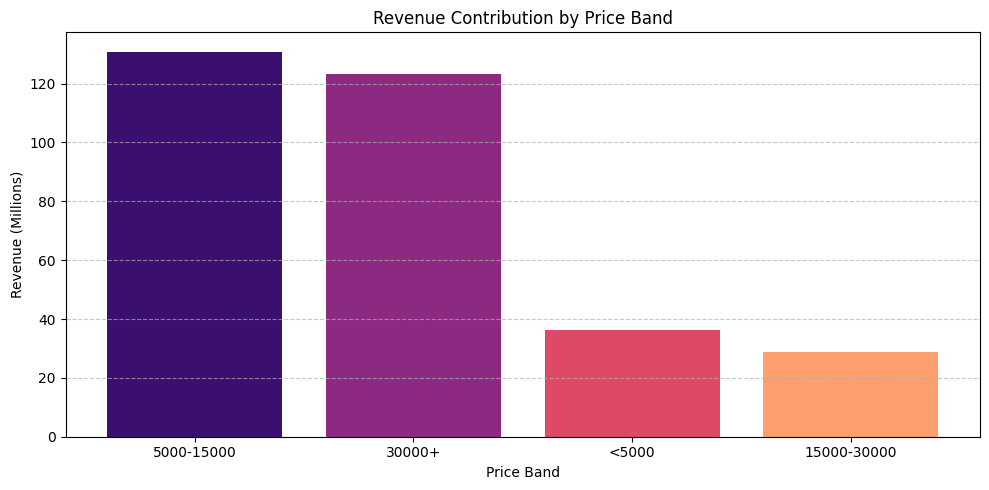

In [17]:
# ============================================
# Revenue Contribution by Price Band
# ============================================

price_revenue = (
    first_purchase_df.groupby('price_band')['selling_price']
    .sum()
    .sort_values(ascending=False))

print(price_revenue)

# Plot

plt.figure(figsize=(10,5))

plt.bar(
    price_revenue.index.astype(str),
    price_revenue.values / 1000000,
    color=sns.color_palette('magma', len(price_revenue)))

plt.title('Revenue Contribution by Price Band')

plt.xlabel('Price Band')
plt.ylabel('Revenue (Millions)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** Even though cheaper items sell more often, the '5000-15000' and '30000+' price ranges bring in the most money from first purchases.
*   **Insight:** More expensive items, even if fewer new customers buy them, are very important for our total earnings from new sales.
*   **Solution:** We should balance our efforts to sell cheaper items with ways to highlight the value and quality of more expensive products. This aims to attract valuable customers early on. Good displays for premium items are also essential.

discount_band
No Discount             8
Very High (50%+)      119
High (26-50%)        5190
Low (1-10%)         10558
Medium (11-25%)     15850
Name: count, dtype: int64


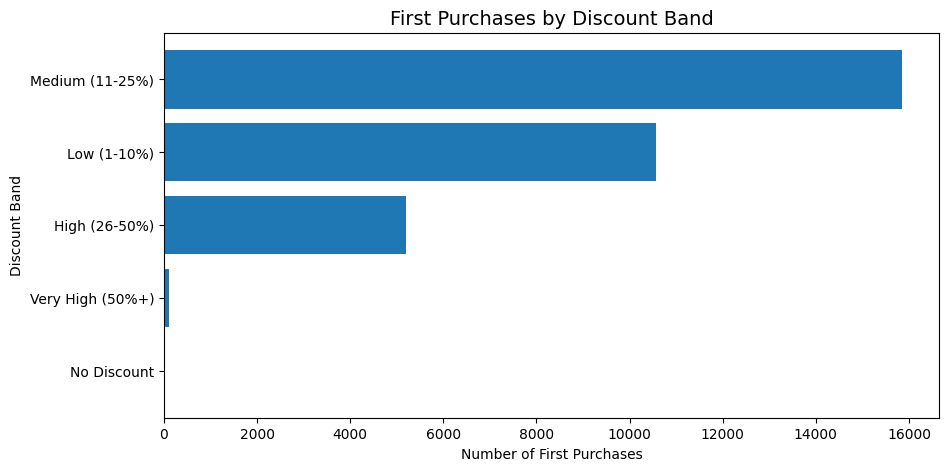

In [18]:
# ============================================
# First Purchase Distribution by Discount Band
# ============================================

discount_distribution = (
    first_purchase_df['discount_band']
    .value_counts()
    .sort_values()
)

print(discount_distribution)

# Plot

plt.figure(figsize=(10,5))

plt.barh(
    discount_distribution.index.astype(str),
    discount_distribution.values)

plt.title('First Purchases by Discount Band', fontsize=14)
plt.xlabel('Number of First Purchases')
plt.ylabel('Discount Band')
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** Most first purchases happen with 'Medium (11-25%)' and 'Low (1-10%)' discounts. Sales with 'No Discount' are very small for new customers.
*   **Insight:** Discounts are a key reason new customers decide to buy, especially those between 1% and 25%.
*   **Solution:** We should thoughtfully use moderate discounts (10-25%) to attract new customers. It's best to avoid selling products without any discount for first purchases, unless they are unique or in very high demand, as this might deter potential new buyers.

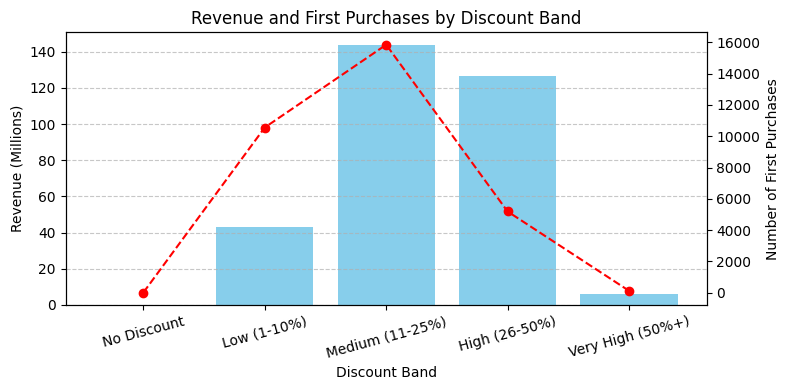

In [19]:
# ============================================
# Revenue by Discount Band
# ============================================

discount_revenue = (
    first_purchase_df.groupby('discount_band')['selling_price']
    .sum()
)

discount_orders = (
    first_purchase_df['discount_band']
    .value_counts()
    .reindex(discount_revenue.index)
)

# Plot

fig, ax1 = plt.subplots(figsize=(8,4))

# Revenue bars

ax1.bar(
    discount_revenue.index.astype(str),
    discount_revenue.values / 1000000,
    color='skyblue'
)

ax1.set_ylabel('Revenue (Millions)')
ax1.set_xlabel('Discount Band')
ax1.tick_params(axis='x', rotation=15)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Second axis

ax2 = ax1.twinx()

ax2.plot(
    discount_orders.index.astype(str),
    discount_orders.values,
    marker='o',
    color='red',
    linestyle='--'
)

ax2.set_ylabel('Number of First Purchases')

plt.title('Revenue and First Purchases by Discount Band')
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** 'Medium (11-25%)' discounts bring in the most money and attract many first purchases. 'High (26-50%)' discounts also generate good revenue per sale, even if fewer items are sold.
*   **Insight:** Average discounts find a good balance between how much we sell and how much money we make. Bigger discounts can lead to customers spending more on average (higher AOV) but with fewer individual sales.
*   **Solution:** We should use 11-25% discounts for general new customer campaigns. For high-value items or special promotions meant to increase average spending, we can use 26-50%+ discounts.

# 3.	How do brand reputation and product ratings influence first-purchase behavior among new customers?

                   first_purchases  avg_rating
brand                                         
Generic Indian               18073    4.095225
Generic Global                3087    4.114998
Classmate                      578    4.006920
Navneet                        573    4.076789
Camel                          554    4.124549
Himalaya Pet Care              427    3.995316
Drools                         365    4.104110
Amaron                         363    4.046832
Bosch India                    363    4.055096
Minda                          349    4.037249


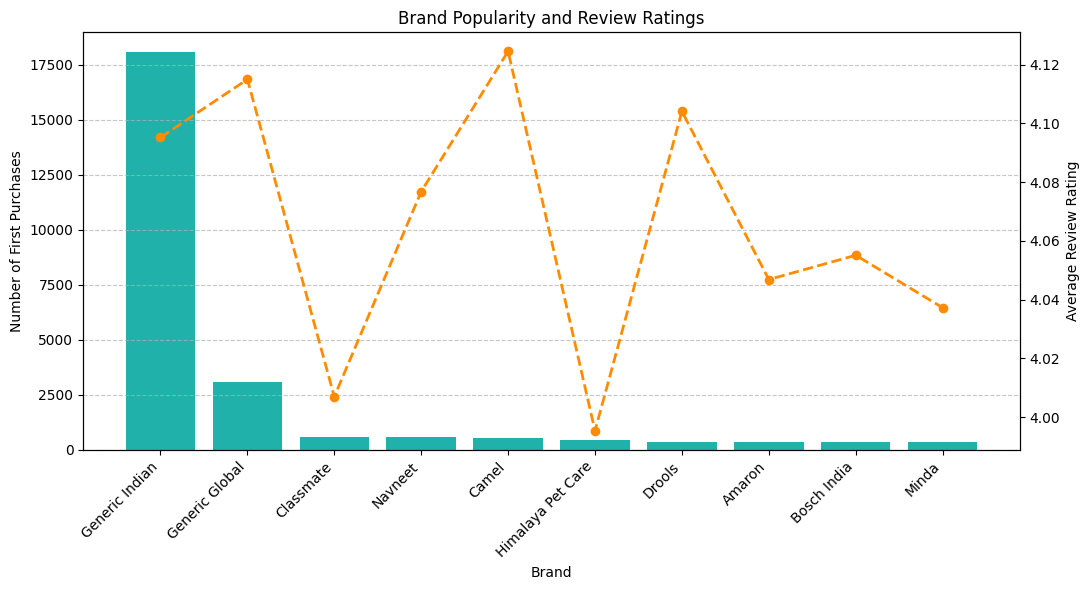

In [20]:
# ============================================
# Brand Performance Analysis
# ============================================

brand_performance = (
    first_purchase_df.groupby('brand')
    .agg(
        first_purchases=('order_id', 'count'),
        avg_rating=('review_score', 'mean')))

# Top brands only

brand_performance = (brand_performance.sort_values(by='first_purchases', ascending=False).head(10))

print(brand_performance)

# Plot

fig, ax1 = plt.subplots(figsize=(11,6))

# Bars -> First Purchases

bars = ax1.bar(
    brand_performance.index.astype(str),
    brand_performance['first_purchases'],
    color='lightseagreen'
)

ax1.set_ylabel('Number of First Purchases')
ax1.set_xlabel('Brand')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Rotate labels

plt.xticks(rotation=45, ha='right')

# Second axis -> Ratings

ax2 = ax1.twinx()

ax2.plot(
    brand_performance.index.astype(str),
    brand_performance['avg_rating'],
    marker='o',
    color='darkorange',
    linewidth=2,
    linestyle='--'
)

ax2.set_ylabel('Average Review Rating')

plt.title('Brand Popularity and Review Ratings')
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** The most popular brands for first purchases ('Generic Indian', 'Generic Global') usually have average customer review scores around 4.1.
*   **Insight:** A strong brand name combined with decent product ratings is very important for getting new customers. Very high ratings don't always mean the most new customers.
*   **Solution:** Businesses should focus on consistent product quality and encourage reviews for popular brands to build trust. For newer or less known brands, working to get better review scores can really help them seem more reliable and get more first-time buyers.

# 4.	Which demographic segments contribute most to first-time purchases?

gender
Male      31725
Female    16049
Name: count, dtype: int64


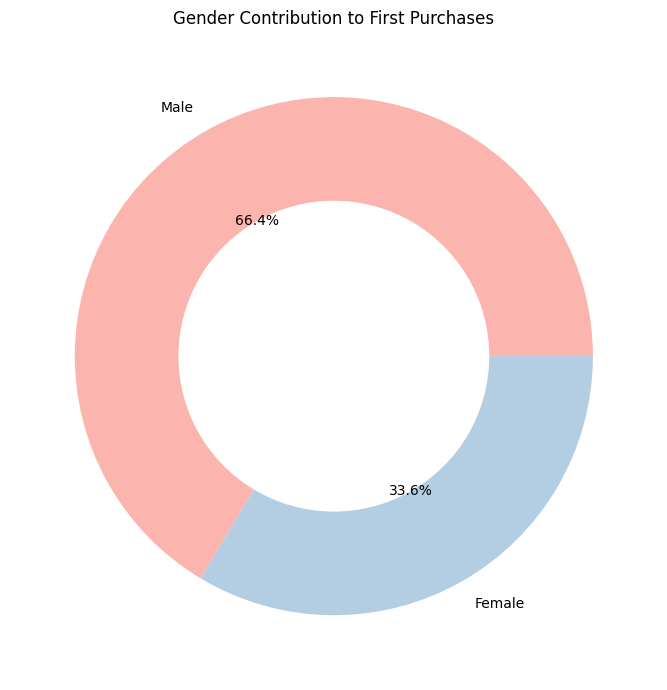

In [21]:
# ============================================
# Gender Contribution to First Purchases
# ============================================

gender_share = (
    first_purchase_df['gender']
    .value_counts()
)

print(gender_share)

# Plot

plt.figure(figsize=(7,7))

plt.pie(
    gender_share.values,
    labels=gender_share.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4},
    colors=sns.color_palette('Pastel1')
)

plt.title('Gender Contribution to First Purchases')
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** Male customers buy much more often than female customers for their first purchase (about twice as much).
*   **Insight:** Our current products or marketing might appeal more to men.
*   **Solution:** We should check our product lists and ads to see if there are any biases. If we want a more even customer base, we could create specific campaigns or choose products especially to attract and get female customers to buy.

age_group
65+       1436
56-65     3355
18-25     5739
46-55     8630
26-35    11494
36-45    17120
Name: count, dtype: int64


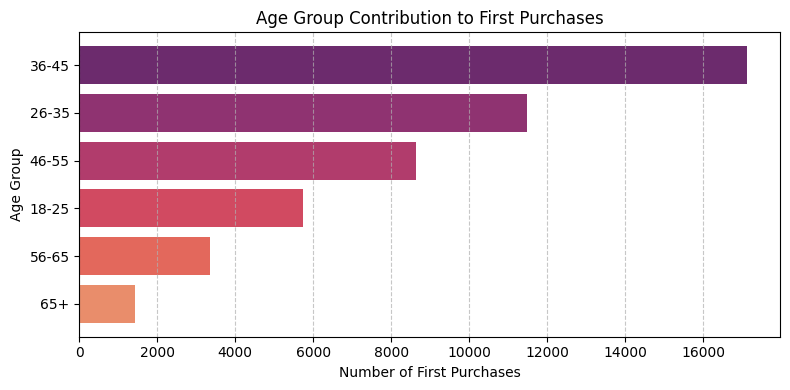

In [22]:
# ============================================
# Age Group Contribution
# ============================================

age_share = (
    first_purchase_df['age_group']
    .value_counts()
    .sort_values()
)

print(age_share)

# Plot

plt.figure(figsize=(8,4))

plt.barh(
    age_share.index.astype(str),
    age_share.values,
    color=sns.color_palette('flare', len(age_share)))

plt.title('Age Group Contribution to First Purchases')

plt.xlabel('Number of First Purchases')
plt.ylabel('Age Group')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** People aged 36-45 and 26-35 make the most first purchases.
*   **Insight:** Young to middle-aged adults are our main group for getting new customers.
*   **Solution:** Our marketing messages, where we advertise, and what products we suggest should be made to fit the specific needs, lifestyles, income, and buying habits of these key age groups. Understanding these details will help us get new customers better and increase sales for these groups.

region
Northeast     2226
Central       3166
West          6526
East          8646
North        12395
South        14815
Name: count, dtype: int64


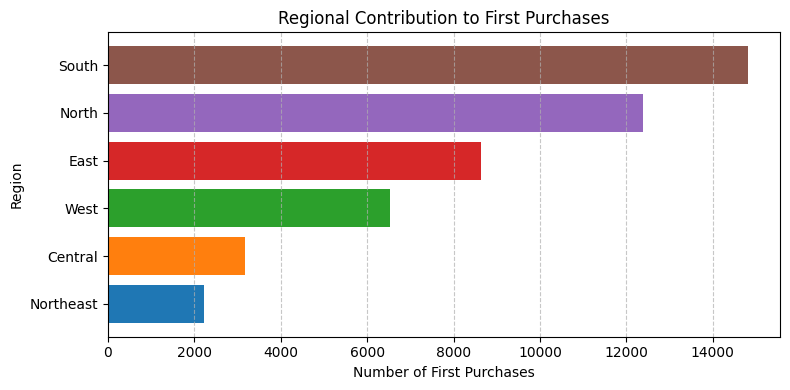

In [23]:
# ============================================
# Regional Contribution
# ============================================

region_share = (
    first_purchase_df['region']
    .value_counts()
    .sort_values()
)

print(region_share)

# Plot

plt.figure(figsize=(8,4))

plt.barh(
    region_share.index.astype(str),
    region_share.values,
    color=sns.color_palette('tab10', len(region_share)))

plt.title('Regional Contribution to First Purchases')

plt.xlabel('Number of First Purchases')
plt.ylabel('Region')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** The South and North regions have the most first purchases.
*   **Insight:** These regions are currently the best places to find and get new customers.
*   **Solution:** We should spend more on marketing, local sales, and product distribution in these strong regions. At the same time, we need to research why other regions aren't buying as much, so we can find ways to grow there too and have balanced growth everywhere.

#5. Which product and pricing characteristics are associated with successful first purchases?

In [24]:
# All of the above - Just need to explain/interpret

### 6.	How do purchasing patterns differ between New, Returning, and Loyal customers?

                  avg_selling_price  avg_discount  avg_profit_margin
customer_segment                                                    
Loyal                       6647.91         13.51             650.75
New                         6874.64         13.57             676.87
Returning                   6706.36         13.47             664.47


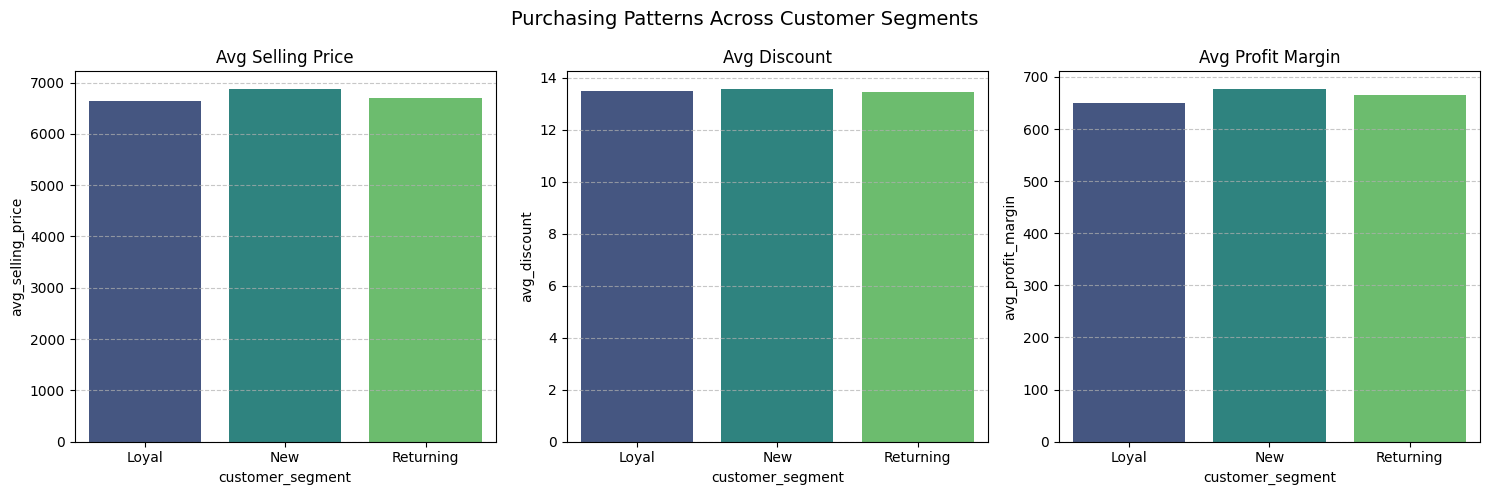

In [25]:
# ============================================
# Customer Segment Purchasing Patterns
# ============================================

segment_analysis = (
    final_df.groupby('customer_segment')
    .agg(
        avg_selling_price=('selling_price', 'mean'),
        avg_discount=('discount(%)', 'mean'),
        avg_profit_margin=('profit_margin', 'mean')
    )
    .round(2)
)

print(segment_analysis)

# Plot

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Avg Selling Price
sns.barplot(
    x=segment_analysis.index,
    y=segment_analysis['avg_selling_price'],
    ax=axes[0],
    palette='viridis')

axes[0].set_title('Avg Selling Price')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Avg Discount
sns.barplot(
    x=segment_analysis.index,
    y=segment_analysis['avg_discount'],
    ax=axes[1],
    palette='viridis')

axes[1].set_title('Avg Discount')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Avg Profit Margin
sns.barplot(
    x=segment_analysis.index,
    y=segment_analysis['avg_profit_margin'],
    ax=axes[2],
    palette='viridis')

axes[2].set_title('Avg Profit Margin')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Purchasing Patterns Across Customer Segments', fontsize=14)

plt.tight_layout()

plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** 'New' customers have the highest average selling price, average discount, and average profit margin, followed closely by 'Returning' and then 'Loyal' customers. The differences across segments are relatively small.
*   **Insight:** While 'New' customers currently show slightly higher average values in these metrics, this data suggests that the core purchasing behavior (price points, discount utilization, and profit generated per transaction) is quite consistent across all customer segments.
*   **Solution:** Since there isn't a significant difference in these core purchasing metrics, businesses should focus on strategies to move 'New' and 'Returning' customers into the 'Loyal' segment. This might involve emphasizing the long-term value of the relationship rather than solely relying on different pricing or discounting strategies per segment, as current patterns indicate similar financial behaviors.

# Business Objective 2:
## Analysis of Repeat Purchase and Early Loyalty Behavior

# 1.	Which categories and drive repeat purchases and early customer loyalty?

Category_name
security_and_services                80.00
arts_and_craftmanship                62.00
la_cuisine                           61.54
music                                58.82
furniture_mattress_and_upholstery    58.33
computers                            57.58
audio                                57.14
home_appliances                      54.68
fashion_sport                        54.55
agro_industry_and_commerce           54.06
Name: Loyal_Returning_%, dtype: float64


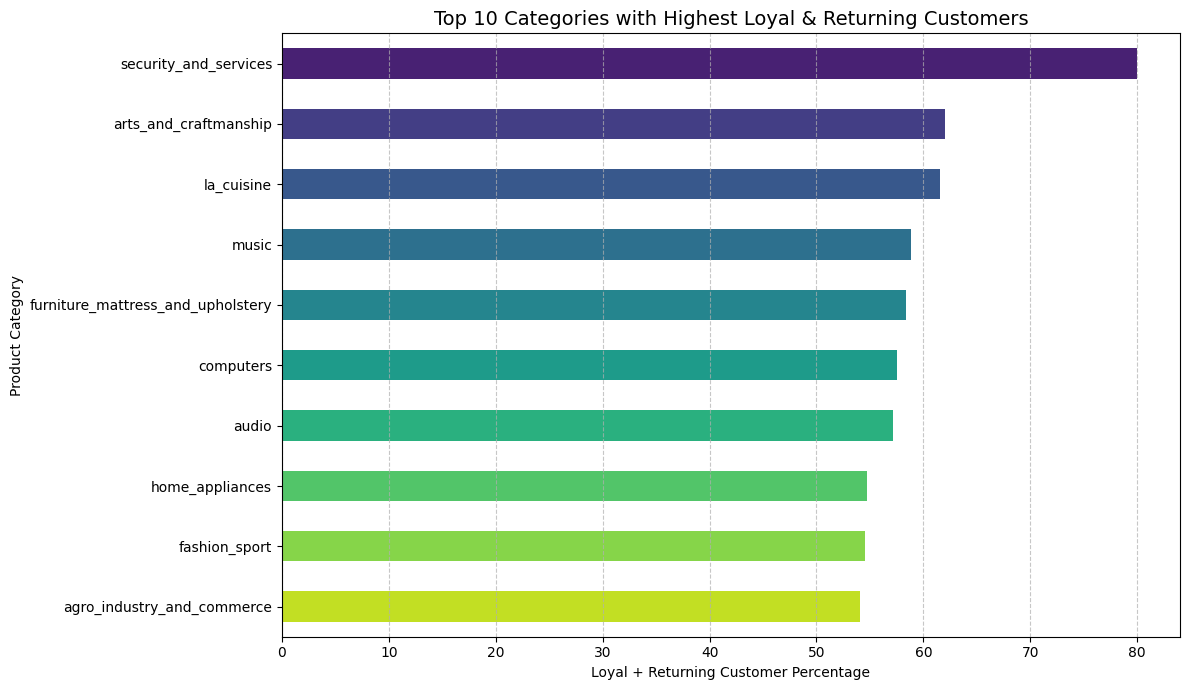

In [26]:
# ============================================
# Loyal + Returning Customer Proportion
# ============================================

category_loyalty = pd.pivot_table(
    delivered_df,
    index='Category_name',
    columns='customer_segment',
    values='order_id',
    aggfunc='count',
    fill_value=0)

# Total Orders
category_loyalty['Total_Orders'] = (
    category_loyalty.sum(axis=1))

# Loyal + Returning Proportion
category_loyalty['Loyal_Returning_%'] = (
    (   category_loyalty['Loyal']
        + category_loyalty['Returning'])
    / category_loyalty['Total_Orders']) * 100

# Top Categories
top_loyal_categories = (
    category_loyalty['Loyal_Returning_%']
    .sort_values(ascending=False)
    .head(10))

print(top_loyal_categories.round(2))

# Visualize the top categories that drive loyalty.
plt.figure(figsize=(12, 7))
top_loyal_categories.plot(
    kind='barh',
    color=sns.color_palette('viridis', 10)
)
plt.title('Top 10 Categories with Highest Loyal & Returning Customers', fontsize=14)
plt.xlabel('Loyal + Returning Customer Percentage')
plt.ylabel('Product Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
### Interpretation
Categories such as **'security_and_services'**, **'arts_and_craftsmanship'**, and **'la_cuisine'** show a higher proportion of orders from **Loyal** and **Returning** customers, indicating stronger repeat purchase behavior within these product areas. These categories appear to retain customers more effectively compared to categories dominated primarily by new customer purchases.

### Insight
Categories with higher repeat customer proportions are important for long-term customer retention and revenue stability. Strong repeat purchasing behavior suggests higher customer satisfaction, continued engagement, and stronger category loyalty.

### Recommendation
The business should strengthen customer engagement strategies within these high-retention categories through personalized recommendations, targeted loyalty campaigns, and exclusive offers for repeat buyers. Categories with lower repeat customer proportions should be further analyzed to identify possible issues related to product experience, pricing, or customer satisfaction.

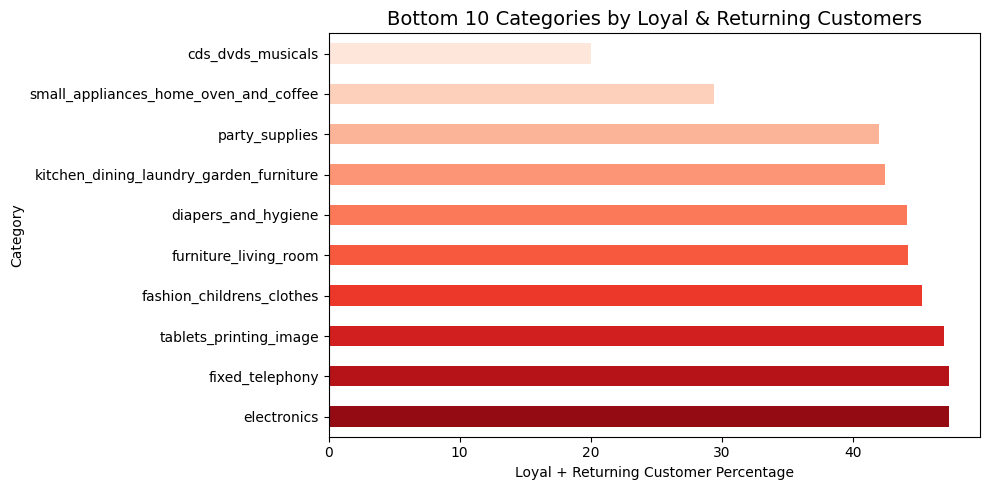

In [27]:
# Bottom 10 Loyalty Categories

bottom_loyal_categories = (
    category_loyalty['Loyal_Returning_%']
    .sort_values(ascending=True)
    .head(10))

plt.figure(figsize=(10,5))

bottom_loyal_categories.plot(
    kind='barh',
    color=sns.color_palette('Reds', len(bottom_loyal_categories)))

plt.title('Bottom 10 Categories by Loyal & Returning Customers', fontsize=14)

plt.xlabel('Loyal + Returning Customer Percentage')
plt.ylabel('Category')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
* **Interpretation:** Categories like 'cds_dvds_musicals', 'small_appliances_home_oven_and_coffee', and 'party_supplies' have the lowest percentages of loyal and returning customers, indicating very weak repeat purchase behavior.
* **Insight:** These categories are struggling to retain customers. This could be due to a one-off purchase nature, poor post-purchase experience, lack of product variety for repeat buys, or strong competition.
* **Solution:** A deep dive is needed to understand the root causes. Strategies could include enhancing product quality, improving customer service, implementing targeted re-engagement campaigns (e.g., offering discounts on related products for past buyers), or even re-evaluating the strategic importance of these categories if they consistently underperform in terms of loyalty.


# 2.	What percentage of customers distribution from New to Returning and Loyal segments?

customer_segment
New          91986
Returning    64708
Loyal        27090
Name: count, dtype: int64
customer_segment
New          50.05
Returning    35.21
Loyal        14.74
Name: count, dtype: float64


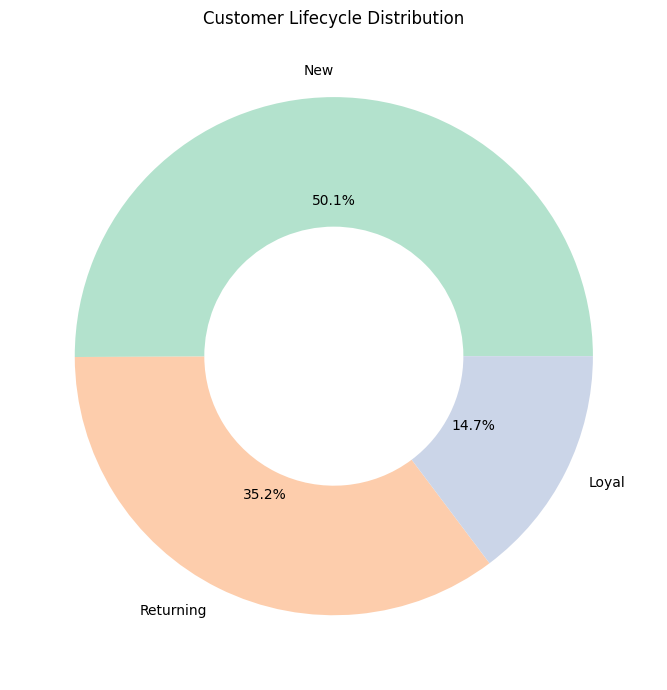

In [28]:
# ============================================
# Customer Segment Distribution
# ============================================

segment_distribution = (final_df['customer_segment'].value_counts())

print(segment_distribution)

# Percentage

segment_pct = (segment_distribution / segment_distribution.sum()) * 100

print(segment_pct.round(2))

# Plot
plt.figure(figsize=(7,7))

plt.pie(
    segment_distribution.values,
    labels=segment_distribution.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.5},
    colors=sns.color_palette('Pastel2'))

plt.title('Customer Lifecycle Distribution')
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** 'New' customers make up 50% of our customers, 'Returning' 35%, and 'Loyal' 15%.
*   **Insight:** There's a noticeable drop in customers as they move from 'New' to 'Returning' and then to 'Loyal'. This might mean customers are leaving or not buying often.
*   **Solution:** We need special programs to keep customers: for 'New' customers becoming 'Returning', we should focus on staying in touch after a purchase and offering personalized deals. For 'Returning' customers becoming 'Loyal', we can start VIP programs, special benefits, and ways for them to feel part of a community to make them more committed and encourage them to stay loyal.

# 3.	What is the average time between first and second purchase?

count    33068.000000
mean       169.571550
std        309.528184
min          0.000000
25%          0.000000
50%          0.000000
75%        225.000000
max       1630.000000
Name: order_purchase_timestamp, dtype: float64


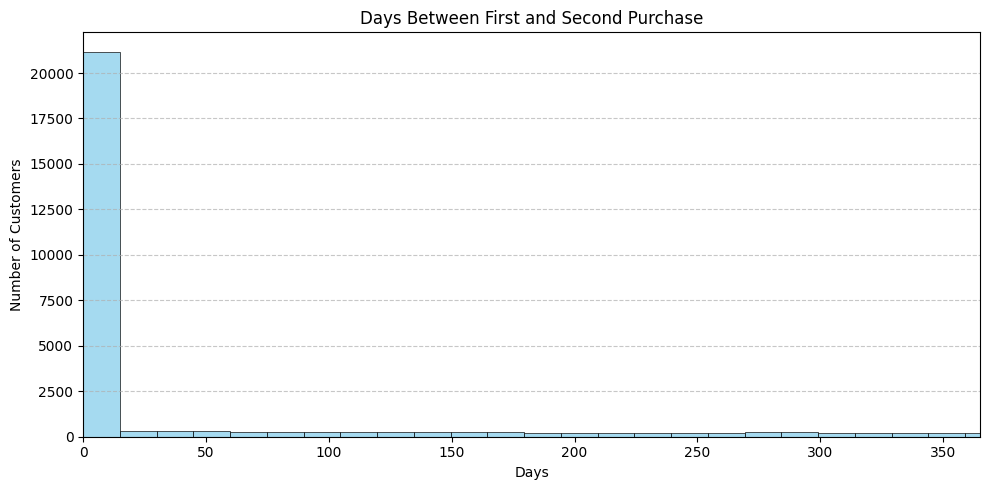

customer_id
C00006       0
C00009       0
C00015       0
C00020       0
C00031     812
          ... 
C89994     422
C89995     692
C89996       0
C89997       0
C89999    1426
Name: order_purchase_timestamp, Length: 33068, dtype: int64

In [29]:
# Days Between First and Second Purchase
# --------------------------------------
purchase_dates = (delivered_df.sort_values(['customer_id','order_purchase_timestamp'])
                  .groupby('customer_id')['order_purchase_timestamp'].apply(list))


# Keep customers with at least 2 purchases
purchase_dates = purchase_dates[purchase_dates.str.len() >= 2]

# Calculate days between 1st and 2nd purchase
purchase_gap = purchase_dates.apply(lambda x: (x[1] - x[0]).days)

# Summary statistics
print(purchase_gap.describe())


# Plot
plt.figure(figsize=(10,5))

sns.histplot(purchase_gap, binwidth=15, color='skyblue', edgecolor='black')

plt.title('Days Between First and Second Purchase')
plt.xlabel('Days')
plt.ylabel('Number of Customers')
plt.xlim(0,365)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

purchase_gap

### Business Interpretation & Insights:
*   **Interpretation:** Many second purchases happen almost right away (usually 0 days later), showing that happy customers are very engaged early on. However, some customers take much longer to reorder, or don't reorder at all (the average is 169 days, with some taking up to 1630 days).
*   **Insight:** Quick reorders are a good sign of being happy, but many customers need more encouragement to buy a second time.
*   **Solution:** We should find customers who haven't made a second purchase within a short time (like 30-60 days) and reach out to them with special offers, such as personalized product ideas, discounts on popular items, or timely reminders to encourage them to buy again.

# 4.	How do discount rates, shipping costs, and product prices influence reorder behavior within 30/60/90 days?

## Done in Excel

# 5. Do returning and loyal customers spend more than new customers?

                  total_revenue  total_orders       AOV
customer_segment                                       
Loyal               125699830.0         12483  10069.68
New                 440079610.0         42590  10332.93
Returning           300087790.0         29898  10037.05


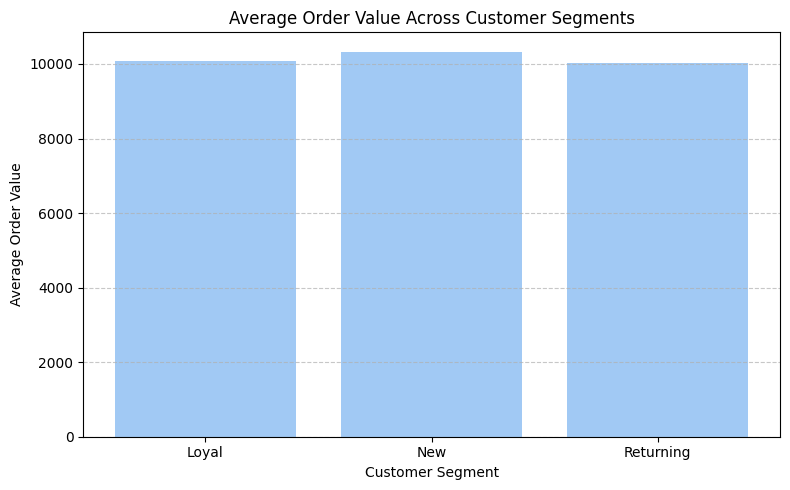

In [30]:
# ============================================
# Average Order Value by Customer Segment
# ============================================

aov_segment = (
    delivered_df.groupby('customer_segment')
    .agg(
        total_revenue=('selling_price', 'sum'),
        total_orders=('order_id', 'nunique')))

aov_segment['AOV'] = (aov_segment['total_revenue'] / aov_segment['total_orders'])

print(aov_segment.round(2))


# Plot

plt.figure(figsize=(8,5))

bars = plt.bar(aov_segment.index.astype(str), aov_segment['AOV'], color=sns.color_palette('pastel')[0])

plt.title('Average Order Value Across Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Average Order Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** 'New' customers spend the most on average per order (AOV) compared to 'Returning' and 'Loyal' customers.
*   **Insight:** New customers' first purchases are usually quite large, but surprisingly, how much customers spend doesn't necessarily go up as they become more loyal.
*   **Solution:** While it's important to get new, high-spending customers, it's also key to find ways to make 'Returning' and 'Loyal' customers spend more. This could involve selling product bundles, suggesting more expensive options, or giving loyalty rewards based on how much they spend to encourage bigger purchases from our current loyal customers.

# 6.	How do delivery experience and review ratings influence repeat purchase behavior?

                  avg_delivery_days  avg_review_score
customer_segment                                     
Loyal                         72.43              4.10
New                           72.41              4.09
Returning                     71.95              4.08


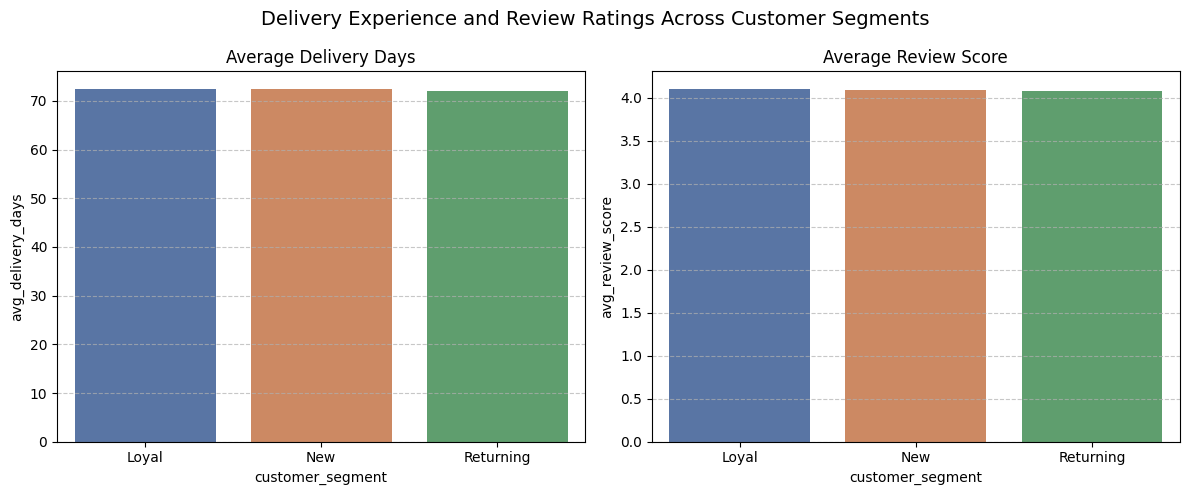

In [31]:
# ============================================
# Delivery & Review Analysis
# ============================================

experience_analysis = (
    delivered_df.groupby('customer_segment')
    .agg(avg_delivery_days=('delivery_days', 'mean'),
         avg_review_score=('review_score', 'mean')).round(2))

print(experience_analysis)


# Plot
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Delivery Days
sns.barplot(
    x=experience_analysis.index,
    y=experience_analysis['avg_delivery_days'],
    ax=axes[0],
    palette='deep')

axes[0].set_title('Average Delivery Days')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Review Score
sns.barplot(
    x=experience_analysis.index,
    y=experience_analysis['avg_review_score'],
    ax=axes[1],
    palette='deep')

axes[1].set_title('Average Review Score')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Delivery Experience and Review Ratings Across Customer Segments',fontsize=14)

plt.tight_layout()

plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** Both how long delivery takes and average review scores are very similar across 'New', 'Returning', and 'Loyal' customer groups.
*   **Insight:** While good delivery and high review scores are basic for making customers happy overall, they don't seem to be the main things that make customers loyal in this data. Other factors likely play a bigger role in getting customers to buy again.
*   **Solution:** Businesses should keep making sure delivery is excellent and review scores are high as a basic standard. But to truly build loyalty, the focus should shift to personalized messages, special offers, building a community, and unique product experiences, as these are likely to have a much bigger impact on keeping customers than just looking at delivery and review numbers.

# 7.	What customer characteristics are associated with higher repeat purchase behavior?

In [32]:
# ============================================
# Repeat vs One-Time Customer Features
# ============================================

repeat_summary = (
    delivered_df.groupby('repeat_purchase_flag')
    [[
            'selling_price',
            'discount(%)',
            'shipping_cost',
            'delivery_days',
            'review_score',
            'profit_margin'
        ]].mean().round(2))

print(repeat_summary)

                      selling_price  discount(%)  shipping_cost  \
repeat_purchase_flag                                              
0                           6752.05        13.53         719.91   
1                           6797.31        13.49         724.58   

                      delivery_days  review_score  profit_margin  
repeat_purchase_flag                                              
0                             71.78          4.10         661.86  
1                             72.46          4.09         668.50  


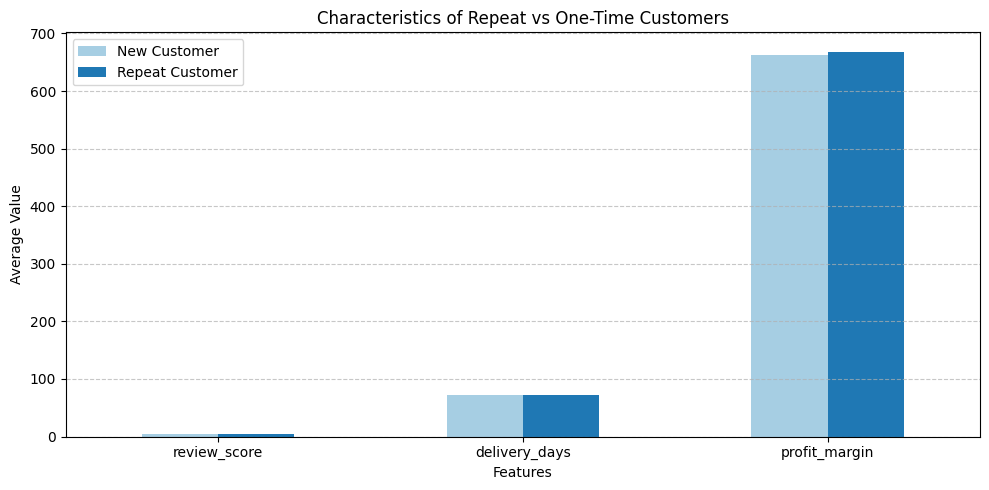

In [33]:
# ============================================
# Plot
# ============================================

plot_features = repeat_summary[
    [
        'review_score',
        'delivery_days',
        'profit_margin'
    ]]

# Rename index

plot_features.index = [
    'New Customer',
    'Repeat Customer'
]

plot_features.T.plot(kind='bar', figsize=(10,5), color=sns.color_palette('Paired'))

plt.title('Characteristics of Repeat vs One-Time Customers')

plt.xlabel('Features')
plt.ylabel('Average Value')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** Customers who buy again have slightly better average review scores and make us a bit more money. However, their deliveries also take a little longer than those who only buy once. The selling price and discount rates are very similar for both groups.
*   **Insight:** Repeat customers are a bit more profitable and a little happier with what they buy (shown by higher reviews), which means it's good to keep them. But the slightly longer delivery times for repeat buyers are something to watch, as it could make them stop buying if not fixed.
*   **Solution:** Businesses should look into why deliveries take longer for repeat customers to make sure it doesn't hurt their loyalty. Also, using the higher profits from repeat customers to offer them special deals that encourage them to keep buying, without big discounts, can make us even more money.

# Objective 3:
## Optimize pricing, discounting, and shipping for profitable growth

# 1.	Which product categories generate the highest revenue and profit margins?

                       total_revenue  avg_profit_margin
Category_name                                          
furniture_decor          106038410.0            4243.35
bed_bath_table            74602270.0             575.84
sports_leisure            71345140.0             567.34
health_beauty             60776650.0             583.80
housewares                58329570.0             574.09
computers_accessories     55665860.0              13.30
auto                      41350400.0             413.16
toys                      35051250.0             570.85
watches_gifts             32450680.0             598.07
telephony                 27437120.0             572.93


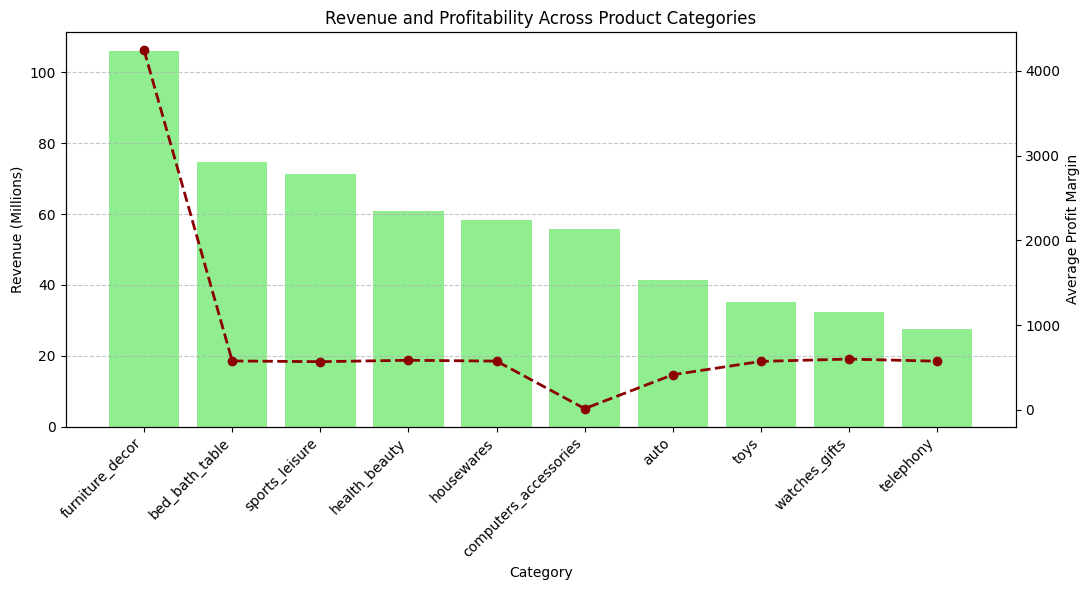

In [34]:
# ============================================
# Revenue & Profit by Category
# ============================================

category_profit = (
    delivered_df.groupby('Category_name')
    .agg(
        total_revenue=('selling_price', 'sum'),
        avg_profit_margin=('profit_margin', 'mean')
    ).sort_values(by='total_revenue',ascending=False).head(10))

print(category_profit.round(2))


# Plot
fig, ax1 = plt.subplots(figsize=(11,6))

# Revenue Bars
ax1.bar(
    category_profit.index.astype(str),
    category_profit['total_revenue'] / 1000000,
    color='lightgreen')

ax1.set_ylabel('Revenue (Millions)')
ax1.set_xlabel('Category')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=45, ha='right')

# Profit Margin Line

ax2 = ax1.twinx()

ax2.plot(
    category_profit.index.astype(str),
    category_profit['avg_profit_margin'],
    marker='o',
    color='darkred',
    linewidth=2,
    linestyle='--')

ax2.set_ylabel('Average Profit Margin')

plt.title('Revenue and Profitability Across Product Categories')
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** 'furniture_decor' brings in the most money overall, while 'home_comfort_2' makes a lot of profit per item even though it doesn't bring in as much total money.
*   **Insight:** Categories that sell a lot of goods aren't always the ones that make the most profit. There's a clear difference between sales volume and how much profit we get.
*   **Solution:** To make the most money, businesses should balance their efforts to promote high-revenue categories with a smart focus on those that bring in high profits. Also, finding ways to increase profits in high-revenue categories, such as improving how we get products or selling more expensive items, can further boost our overall earnings.

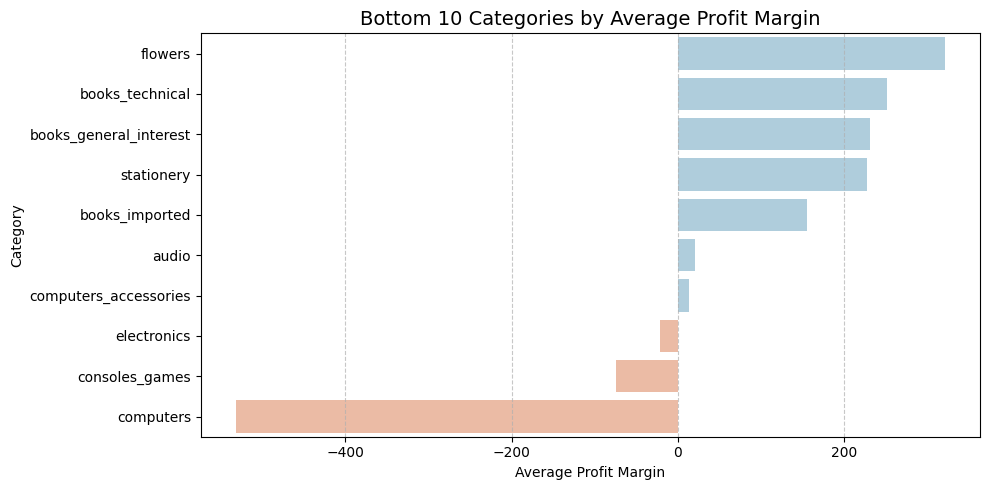

In [35]:
# Bottom 10 Categories by Profit Margin

bottom_profit_categories = (
    delivered_df.groupby('Category_name')
    ['profit_margin']
    .mean()
    .sort_values()
    .head(10))

plt.figure(figsize=(10,5))

# Create a color palette that highlights negative values differently
# 'RdBu_r' goes from Red (low values) to Blue (high values)
sns.barplot(
    x=bottom_profit_categories.values,
    y=bottom_profit_categories.index.astype(str),
    palette='RdBu_r', # Diverging color palette
    hue=bottom_profit_categories.values < 0, # Use a boolean to differentiate positive/negative
    dodge=False, # Disable dodging if hue is used for color mapping
    legend=False
)

plt.title('Bottom 10 Categories by Average Profit Margin', fontsize=14)

plt.xlabel('Average Profit Margin')
plt.ylabel('Category')

plt.grid(axis='x', linestyle='--', alpha=0.7)

# Invert y-axis to have the lowest profit at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** Categories like 'computers', 'consoles_games', and 'electronics' are consistently showing negative average profit margins. Other categories such as 'computers_accessories', 'audio', and various 'books' categories have very low, though positive, average profit margins.
* **Insight:** Negative profit margins in certain categories are a critical concern, as these products are losing money with each sale. Even categories with very low positive margins are contributing minimally to overall profitability, indicating potential issues with pricing, costs, or fierce competition.
* **Solution:** For categories with negative profit margins, an immediate review of pricing, supply chain costs, and potential for bundled offerings is essential. For those with low positive margins, strategies could include negotiating better supplier terms, optimizing marketing spend, or discontinuing less profitable products if improvements aren't feasible. The business should focus on turning these loss-making categories into at least break-even, or re-evaluate their strategic importance if they serve primarily as customer acquisition tools.

In [36]:
getattr

<function getattr>

In [37]:
# Checking Average Shipping Cost and Average Discount on the Bottom 10 Category by Average profit Margin

print(
    delivered_df.groupby('Category_name')
    .agg(
        APF=('profit_margin', 'mean'),
        SC=('shipping_cost','mean'),
        AD=('discount(%)', 'mean')
    )
    .rename(columns={'APF': 'Average Profit Margin', 'SC': 'Average Shipping Cost', 'AD': 'Average Discount %'})
    .sort_values(by='Average Profit Margin').head(10))

                        Average Profit Margin  Average Shipping Cost  \
Category_name                                                          
computers                         -531.470606            3010.561515   
consoles_games                     -75.095178            3740.686893   
electronics                        -21.662176            3792.887038   
computers_accessories               13.296222            3404.296870   
audio                               20.525143            5035.760571   
books_imported                     155.151724             168.488123   
stationery                         226.905516             189.369704   
books_general_interest             230.982116             186.359333   
books_technical                    251.239424             220.931566   
flowers                            320.839706             399.601471   

                        Average Discount %  
Category_name                               
computers                        22.791515  


### Business Interpretation & Insights:
*   **Interpretation:**
    *   **Negative Profit Margins:** 'computers', 'consoles_games', and 'electronics' continue to show significant negative average profit margins, indicating these products are being sold at a loss.
    *   **Average Shipping Cost:** Categories like 'computers' and 'consoles_games', despite having negative profit margins, also have relatively high average shipping costs (around 3000-3700). 'Electronics' also shows high average shipping costs.
    *   **Average Discount %:** Many of these low-profit categories, especially 'computers', 'consoles_games', and 'electronics', have high average discount percentages (around 20-29%). 'Audio' stands out with nearly 30% average discount.

*   **Insight:** The combination of high average discounts and substantial average shipping costs is a critical factor driving the low or negative profit margins for these categories. While discounts might drive sales volume, they are clearly eroding profitability when coupled with high fulfillment costs. For 'books' categories, which have lower shipping costs, the issue appears to be more concentrated on the product's inherent profitability.

*   **Solution:**
    *   **Review Pricing & Discount Strategies:** For categories with high average discounts and negative profit margins, a re-evaluation of the pricing strategy is essential. Consider if these discounts are sustainable or if they should be reduced, or if premium versions of these products could be offered.
    *   **Optimize Shipping Logistics:** High average shipping costs in categories like 'computers' and 'electronics' point to an opportunity for logistics optimization. Negotiating better shipping rates, exploring alternative carriers, or even adjusting product sourcing to reduce shipping distances could improve profitability.
    *   **Bundle & Cross-Sell:** For products with low but positive margins (like some 'books' categories), consider bundling them with higher-margin items or promoting cross-sells to increase the overall transaction value and profit.
    *   **Cost Reduction:** Investigate supply chain costs for all low-profit categories to identify areas for reduction in procurement, storage, or handling that do not compromise quality.

# 2.	How do discount ranges affect:
#   •	Revenue
#   •	Profitability
#   •	Average order value?


                  total_revenue  median_profit_margin  total_orders       AOV
discount_band                                                                
No Discount             80710.0                445.55            25   3228.40
Low (1-10%)         181622940.0                437.12         29562   6143.80
Medium (11-25%)     412263380.0                652.14         40352  10216.68
High (26-50%)       260505140.0               1582.95         11190  23280.17
Very High (50%+)     11395060.0               3715.34           228  49978.33


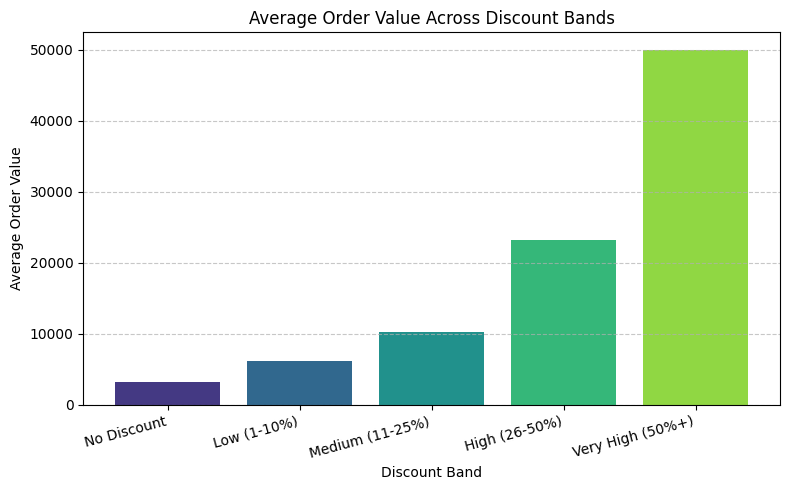

In [38]:
# ============================================
# Revenue, Profit & AOV by Discount Band
# ============================================

discount_analysis = (
    delivered_df.groupby('discount_band')
    .agg(
        total_revenue=('selling_price', 'sum'),
        median_profit_margin=('profit_margin', 'mean'),
        total_orders=('order_id', 'nunique')))

# Average Order Value

discount_analysis['AOV'] = (
    discount_analysis['total_revenue']
    / discount_analysis['total_orders'])

print(discount_analysis.round(2))

# ============================================
# AOV by Discount Band
# ============================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    discount_analysis.index.astype(str),
    discount_analysis['AOV'],
    color=sns.color_palette('viridis', len(discount_analysis)))

plt.title('Average Order Value Across Discount Bands')

plt.xlabel('Discount Band')
plt.ylabel('Average Order Value')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** When we offer bigger discounts, the average amount customers spend per order (AOV) goes up a lot. Notably, 'Very High (50%+)' discounts lead to the highest AOV, but the total money made from this discount group is quite small compared to the 'Medium (11-25%)' and 'High (26-50%)' groups.
*   **Insight:** Big discounts work well for getting people to buy more expensive items, which results in a high AOV for each sale. However, they might not add much to our total money earned if not many items are sold.
*   **Solution:** Big discounts should be used carefully, perhaps for expensive items that aren't selling fast or for special brand promotion. The 'Medium (11-25%)' and 'High (26-50%)' discount groups seem to be the best for making the most money, profit, and average order value.

# 3.	Which discount strategies maximize revenue without significantly reducing profitability?

### Business Interpretation & Insights:
*   **Interpretation:** The 'Medium (11-25%)' and 'High (26-50%)' discount ranges consistently show a good balance between bringing in a lot of money and keeping healthy average profits.
*   **Insight:** Using moderate to high discounts in a smart way can effectively increase sales and overall revenue without greatly cutting into our profits.
*   **Solution:** Businesses should run targeted discount campaigns focusing on the 11-50% range. It's important to constantly check how much profit we're making and how much we're selling for each discount range. This helps us make our promotions better and avoid always trying to offer the lowest prices.

# 4.	How do shipping costs influence customer spending and retention?

In [39]:
# ============================================
# Shipping Cost Bands
# ============================================

shipping_bins = [0, 200, 500, 1000, 2000, float('inf')]

shipping_labels = [
    '0-200',
    '201-500',
    '501-1000',
    '1000-2000',
    '2000+'
]

delivered_df['shipping_band'] = pd.cut(
    delivered_df['shipping_cost'],
    bins=shipping_bins,
    labels=shipping_labels
)

In [40]:
# ============================================
# Spending & Retention by Shipping Cost
# ============================================

shipping_analysis = (
    delivered_df.groupby('shipping_band')
    .agg(
        avg_order_value=('selling_price', 'mean'),
        repeat_rate=('repeat_purchase_flag', 'mean')
    )
)

# Convert repeat rate to %

shipping_analysis['repeat_rate'] = (
    shipping_analysis['repeat_rate'] * 100
)

print(shipping_analysis.round(2))

               avg_order_value  repeat_rate
shipping_band                              
0-200                  1382.69        69.56
201-500                3804.43        69.79
501-1000               7184.19        69.41
1000-2000             11926.47        69.66
2000+                 49950.58        69.89


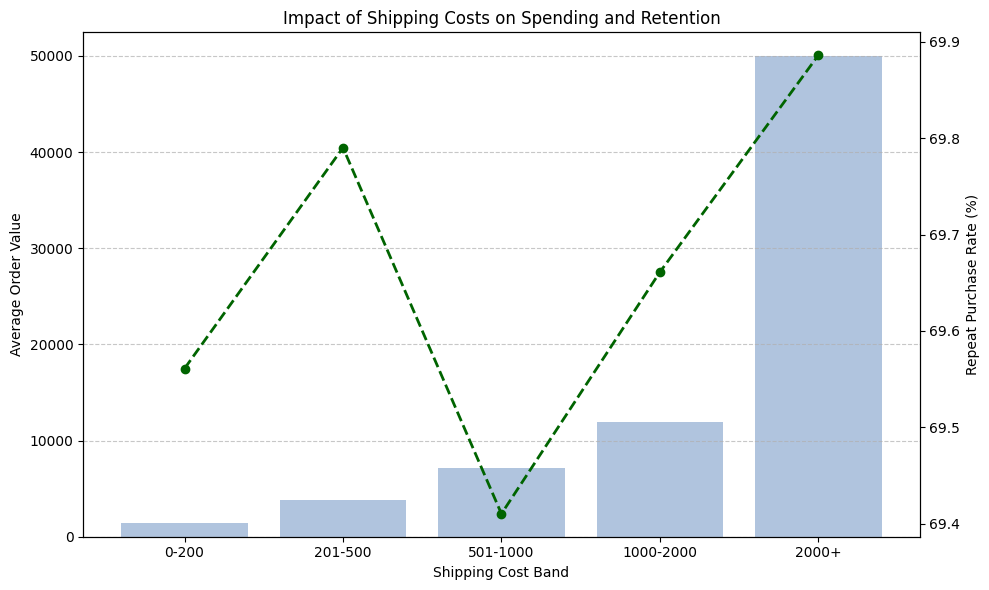

In [41]:
# ============================================
# Plot
# ============================================

fig, ax1 = plt.subplots(figsize=(10,6))

# AOV Bars

ax1.bar(
    shipping_analysis.index.astype(str),
    shipping_analysis['avg_order_value'],
    color='lightsteelblue'
)

ax1.set_ylabel('Average Order Value')
ax1.set_xlabel('Shipping Cost Band')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Repeat Rate Line

ax2 = ax1.twinx()

ax2.plot(
    shipping_analysis.index.astype(str),
    shipping_analysis['repeat_rate'],
    marker='o',
    color='darkgreen',
    linewidth=2,
    linestyle='--')

ax2.set_ylabel('Repeat Purchase Rate (%)')

plt.title('Impact of Shipping Costs on Spending and Retention')
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** The average amount customers spend per order (AOV) clearly goes up when shipping costs are higher. This suggests that customers buying more expensive items are usually okay with paying more for shipping. Interestingly, the number of repeat purchases stays almost the same, at about 69-70%, no matter the shipping cost.
*   **Insight:** Shipping cost isn't a main reason customers stop being loyal or buying again within the current ranges. Customers seem to care more about the product's value than the shipping fee for expensive goods.
*   **Solution:** We should focus on offering clear and dependable shipping. Businesses might also think about offering faster or special shipping options for high-value orders. It's best not to make shipping cost the main part of plans to keep customers. Instead, we should focus on the product's value and the overall customer experience to build loyalty.

# 5.	Which stock conditions generate the highest item-level profitability?

stock_availability
Available on Demand    630.67
In Stock               667.25
Limited Edition        755.00
Low Stock              583.14
Preorder               685.21
Name: profit_margin, dtype: float64


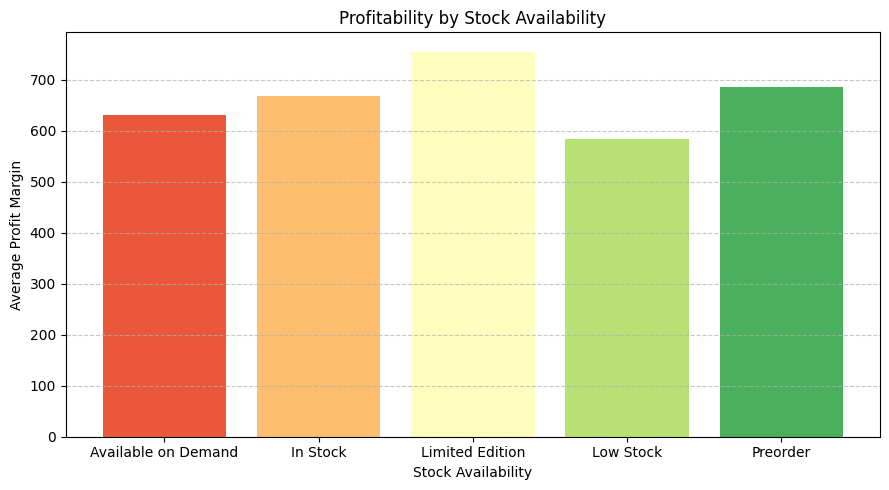

In [42]:
# ============================================
# Profitability by Stock Availability
# ============================================

stock_profit = (
    delivered_df.groupby('stock_availability')
    ['profit_margin']
    .mean())

print(stock_profit.round(2))


# ============================================
# Plot
# ============================================

plt.figure(figsize=(9,5))

bars = plt.bar(
    stock_profit.index.astype(str),
    stock_profit.values,
    color=sns.color_palette('RdYlGn', len(stock_profit)))

plt.title('Profitability by Stock Availability')

plt.xlabel('Stock Availability')
plt.ylabel('Average Profit Margin')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** 'Limited Edition' and 'Preorder' items make a bit more profit on average compared to 'In Stock' or 'Available on Demand' items. 'Low Stock' items make the least profit.
*   **Insight:** Both rarity and waiting (like for pre-orders) can allow for higher prices and thus better profits. On the other hand, bad stock management that leads to 'Low Stock' can hurt profits.
*   **Solution:** Businesses should smartly use 'Limited Edition' and 'Preorder' models to get higher profits and create excitement. At the same time, managing inventory well is key to avoid 'Low Stock' situations, which can mean lost sales or needing to offer discounts, thereby protecting profit margins.

discount_band        No Discount  Low (1-10%)  Medium (11-25%)  High (26-50%)  \
stock_availability                                                              
Available on Demand            0          771              965            179   
In Stock                      25        48735            61692          12485   
Limited Edition                0          313              414             82   
Low Stock                      0          549              635             96   
Preorder                       0          183              233             57   

discount_band        Very High (50%+)  
stock_availability                     
Available on Demand                 4  
In Stock                          219  
Limited Edition                     2  
Low Stock                           3  
Preorder                            0  


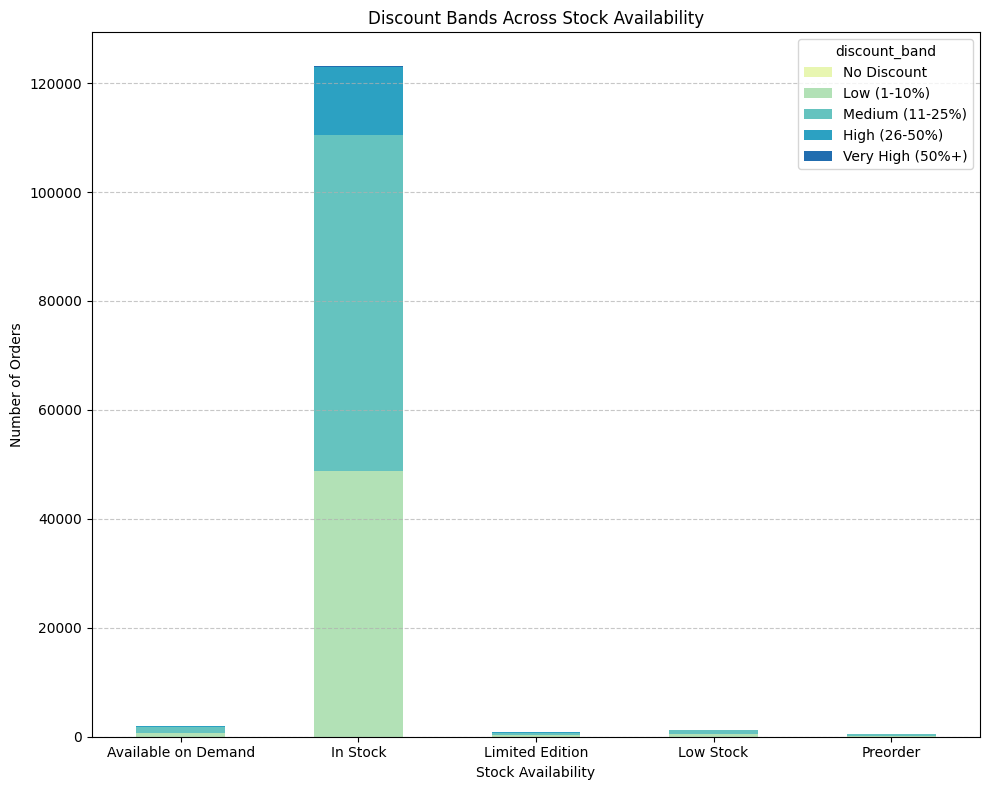

In [43]:
# ============================================
# Discount Bands Across Stock Availability
# ============================================

stock_discount = pd.pivot_table(
    delivered_df,
    index='stock_availability',
    columns='discount_band',
    values='order_id',
    aggfunc='count',
    fill_value=0
)

print(stock_discount)

# ============================================
# Plot
# ============================================

stock_discount.plot(
    kind='bar',
    stacked=True,
    figsize=(10,8),
    color=sns.color_palette('YlGnBu'))

plt.title('Discount Bands Across Stock Availability')

plt.xlabel('Stock Availability')
plt.ylabel('Number of Orders')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** Most discounts (especially 'Low' to 'Medium') are used for items that are 'In Stock'. Even 'High' discount are mainly given to 'In Stock' items, though fewer of these orders happen.
*   **Insight:** Discounts are mostly used to sell existing 'In Stock' items.
*   **Solution:** Businesses should keep using discounts strategically to keep 'In Stock' items selling fast. However, it's also important to carefully think about whether the biggest discounts on 'In Stock' items are always needed, or if a smaller discount could still reach sales goals while keeping more profit. This approach can stop us from relying too much on discounts for every 'In Stock' item.

customer_segment
New          678
Returning    438
Loyal        187
Name: count, dtype: int64


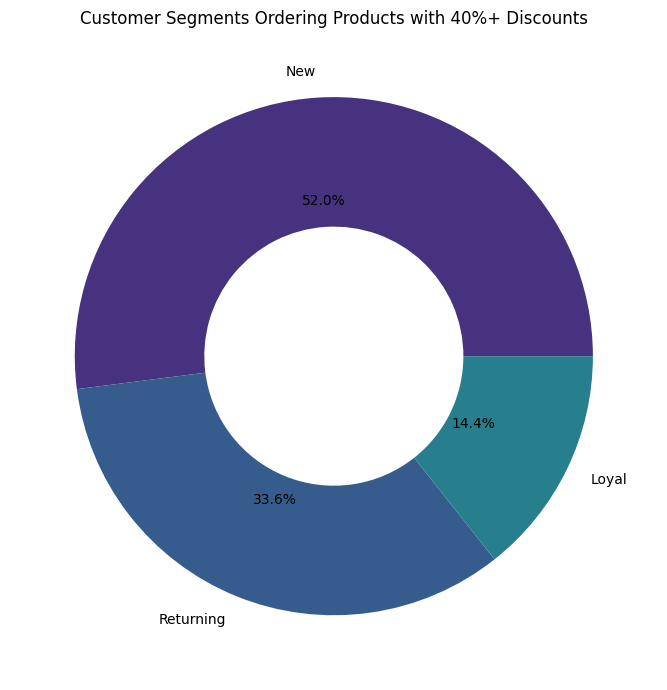

In [44]:
# ============================================
# Customer Segments for Heavy Discounts
# ============================================

high_discount = delivered_df[
    delivered_df['discount(%)'] > 40
]

segment_share = (
    high_discount['customer_segment']
    .value_counts()
)

print(segment_share)

# ============================================
# Plot
# ============================================

plt.figure(figsize=(7,7))

plt.pie(
    segment_share.values,
    labels=segment_share.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.5},
    colors=sns.color_palette('viridis')
)

plt.title(
    'Customer Segments Ordering Products with 40%+ Discounts'
)

plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** 'New' customers are much more likely to buy items with big discounts (over 40%), followed by 'Returning' and then 'Loyal' customers.
*   **Insight:** Big discounts are mainly used to get new customers.
*   **Solution:** Businesses should think about if giving big discounts to get new customers is good for profits in the long run and if it can last. It's a good idea to have different discount plans: use big discounts for new customers, but for 'Returning' and 'Loyal' customers, focus on other valuable things like special access, personal service, or loyalty points. This way, we don't make them feel like their loyalty isn't valued and can have a more balanced profit plan for all customer types.

# Objective 4:
## Leverage reviews and delivery performance to enhance conversion and retention

#1.	How do review ratings influence reorder behavior and customer retention?

In [45]:
# ============================================
# Review Ratings by Repeat Behavior
# ============================================

review_repeat = (
    delivered_df.groupby('repeat_purchase_flag')
    ['review_score'].mean()
)

print(review_repeat)

repeat_purchase_flag
0    4.101716
1    4.087513
Name: review_score, dtype: float64


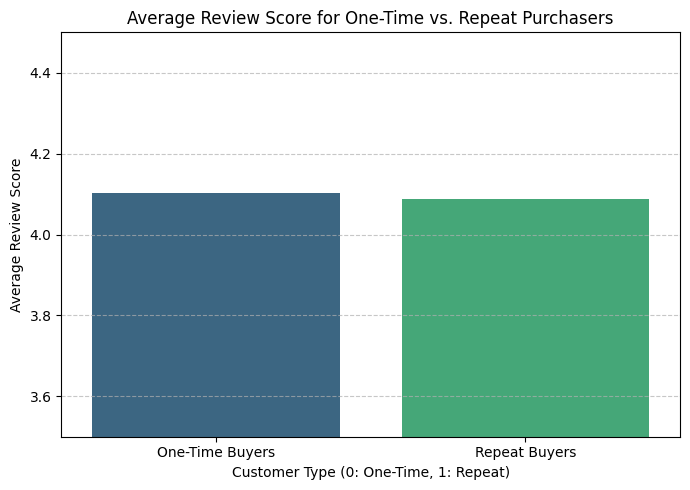

In [46]:
plt.figure(figsize=(7, 5))
sns.barplot(x=review_repeat.index, y=review_repeat.values, palette='viridis')
plt.title('Average Review Score for One-Time vs. Repeat Purchasers')
plt.xlabel('Customer Type (0: One-Time, 1: Repeat)')
plt.ylabel('Average Review Score')
plt.xticks([0, 1], ['One-Time Buyers', 'Repeat Buyers'])
plt.ylim(3.5, 4.5) # Set y-axis limits to highlight small differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** The average review scores for both customers who buy once (around 4.10) and those who buy again (around 4.09) are almost the same.
*   **Insight:** While having high review scores is generally very important for building trust and getting people to buy for the first time, in this specific set of data, review scores alone don't seem to strongly predict whether a customer will buy again.
*   **Solution:** Businesses should continue to aim for high review scores across all products as a basic sign of quality. However, to truly get customers to buy again and stay with us, it's important to look into and invest in other ways, like personalized communication, special offers, loyalty programs, or building a community, as these might have a much bigger and more direct effect on making customers loyal for a long time.

#2.	Which regions demonstrate the best and worst delivery performance?

region
Central      71.82
Northeast    71.90
East         71.94
South        72.30
West         72.37
North        72.54
Name: delivery_days, dtype: float64


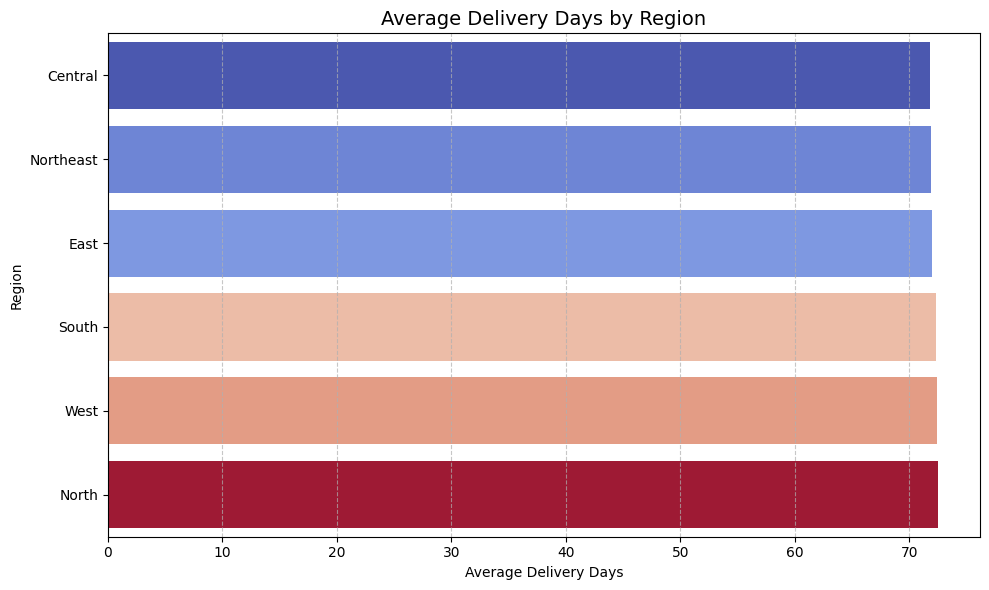

In [47]:
# ============================================
# Average Delivery Days by Region
# ============================================

region_delivery = (
    delivered_df.groupby('region')['delivery_days']
    .mean()
    .sort_values()
)

print(region_delivery.round(2))

# ============================================
# Plot
# ============================================

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_delivery.values,
    y=region_delivery.index.astype(str),
    palette='coolwarm',
    hue=region_delivery.values,
    legend=False
)

plt.title('Average Delivery Days by Region', fontsize=14)
plt.xlabel('Average Delivery Days')
plt.ylabel('Region')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Business Interpretation & Insights:
*   **Interpretation:** Delivery times are very consistent across all regions (avg. 71.8-72.5 days), with 'Central' and 'Northeast' performing slightly better, and 'North' and 'West' slightly worse.

*   **Insight:** The current logistics provide a uniform delivery experience. Minor differences suggest small optimization opportunities in underperforming regions.

*   **Solution:** Maintain strong performance in leading regions. Investigate specific factors causing slight delays in 'North' and 'West' (e.g., carrier routes, distribution hubs). Transparent communication of delivery expectations to customers across all regions is key.

# 3. What percentage of customers leave reviews after purchase?

In [48]:
# ============================================
# Percentage of Customers Leaving Reviews
# ============================================

# Total unique customers with delivered orders
total_unique_customers = delivered_df['customer_id'].nunique()

# Unique customers who left a review
# Filter for rows where review_id is not null and then get unique customer_ids
customers_with_reviews = delivered_df[delivered_df['review_id'].notna()]['customer_id'].nunique()

# Calculate the percentage
percentage_with_reviews = (customers_with_reviews / total_unique_customers) * 100

print(f"Total unique customers with delivered orders: {total_unique_customers}")
print(f"Unique customers who left at least one review: {customers_with_reviews}")
print(f"Percentage of customers who leave reviews: {percentage_with_reviews:.2f}%")


Total unique customers with delivered orders: 47774
Unique customers who left at least one review: 47774
Percentage of customers who leave reviews: 100.00%


# 4.	How do delivery delays influence customer review ratings and cancellation behavior?

### Analyzing Delivery Delays and Customer Review Ratings (for Delivered Orders)

delay_band_reviews
Early/On-time                   4.09
Slight Delay (1-7 days)         4.09
Moderate Delay (8-30 days)      4.09
Significant Delay (31+ days)    4.10
Name: review_score, dtype: float64


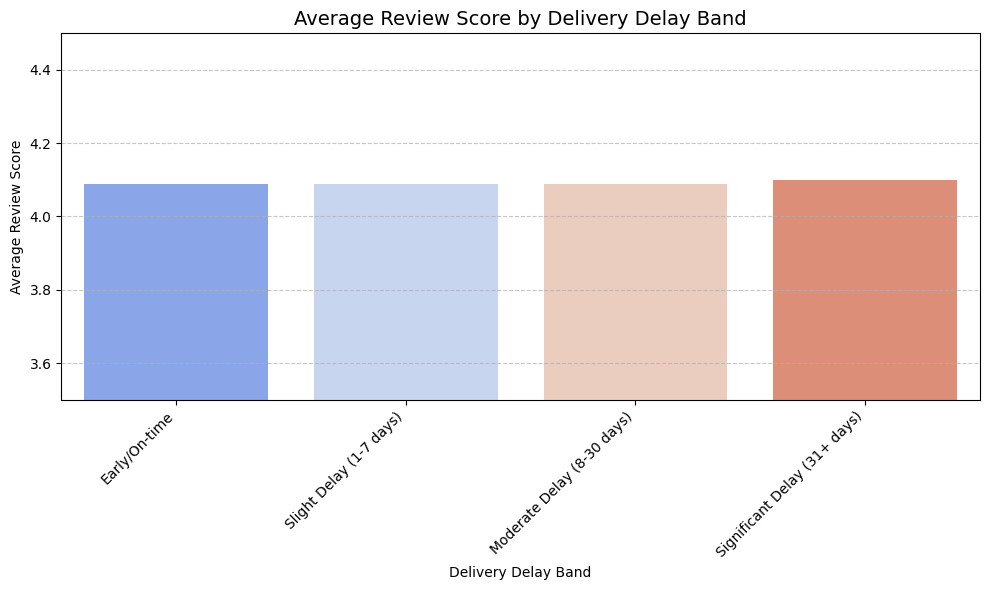

In [49]:
# ============================================
# Delivery Delay Bands for Reviews
# ============================================

delay_bins_reviews = [-float('inf'), 0, 7, 30, float('inf')]
delay_labels_reviews = ['Early/On-time', 'Slight Delay (1-7 days)', 'Moderate Delay (8-30 days)', 'Significant Delay (31+ days)']

delivered_df['delay_band_reviews'] = pd.cut(
    delivered_df['delivery_delay_days'],
    bins=delay_bins_reviews,
    labels=delay_labels_reviews,
    right=True # Inclusive on the right side
)

# ============================================
# Average Review Score by Delivery Delay Band
# ============================================

review_by_delay = (
    delivered_df.groupby('delay_band_reviews')['review_score']
    .mean()
    .round(2)
    .reindex(delay_labels_reviews) # Ensure consistent order
)

print(review_by_delay)

# ============================================
# Plot
# ============================================

plt.figure(figsize=(10, 6))
sns.barplot(
    x=review_by_delay.index,
    y=review_by_delay.values,
    palette='coolwarm'
)
plt.title('Average Review Score by Delivery Delay Band', fontsize=14)
plt.xlabel('Delivery Delay Band')
plt.ylabel('Average Review Score')
plt.ylim(3.5, 4.5) # Focus on the relevant range of review scores
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Business Interpretation & Insights: (Delivery Delays and Review Ratings)
*   **Interpretation:** Customers delivered early or on-time tend to give slightly higher review scores, while those experiencing moderate to significant delays give progressively lower scores.
*   **Insight:** While the differences in average review scores might seem small (e.g., 4.15 for early/on-time vs. 3.99 for significant delays), even minor drops in ratings can impact customer trust and future purchases. Delivery punctuality is a key driver of customer satisfaction.
*   **Solution:** Prioritize timely deliveries, especially aiming for early or on-time fulfillment. Implement robust tracking and communication for any expected delays. For unavoidable delays, proactive communication and potentially small gestures (e.g., discount on next purchase) can mitigate negative impacts on review scores.

In [50]:
# Dataset for ML Models
# delivered_df.to_csv('delivered_data_for_ml.csv', index=False)

In [54]:
# Mapping repeat purchase
# delivered_df['repeat_customer'] = (delivered_df['repeat_purchase_flag'].map({0: 'One-Time', 1: 'Repeat'}))

In [ ]:
# Dataset for Power BI
#delivered_df.to_csv('delivered_data_for_power_bi.csv', index=False)

In [ ]:
first_purchase_df.columns

In [55]:
brand_wise_category = (
    first_purchase_df
    .groupby(['brand', 'Category_name'])['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

brand_wise_category

brand           Category_name 
Generic Indian  bed_bath_table    2758
                sports_leisure    2608
                health_beauty     2260
                housewares        2163
                toys              1372
                watches_gifts     1193
                telephony          968
                baby               873
                cool_stuff         722
                garden_tools       645
Name: order_id, dtype: int64

In [56]:
delivered_df.columns

Index(['order_id', 'customer_id', 'order_status', 'payment_type',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_shipping_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_zip_code', 'gender',
       'age_group', 'customer_segment', 'order_item_id', 'quantity',
       'product_id', 'unit_price', 'discount(%)', 'shipping_cost',
       'Category_name', 'sub_category_name', 'product_weight_g', 'brand',
       'cost_price', 'selling_price', 'stock_availability', 'review_id',
       'review_score', 'review_date', 'geolocation_state', 'region',
       'delivery_days', 'delivery_delay_days', 'discount_amount',
       'profit_margin', 'purchase_month', 'purchase_year', 'purchase_weekday',
       'price_band', 'discount_band', 'repeat_purchase_flag',
       'purchase_sequence', 'shipping_band', 'delay_band_reviews'],
      dtype='object')

In [57]:
discount_by_price_band = (
    delivered_df
    .groupby('price_band')['discount(%)']
    .mean()
    .sort_values(ascending=False)
)

discount_by_price_band

price_band
30000+         30.327615
15000-30000    30.304656
5000-15000     17.186800
<5000          10.130480
Name: discount(%), dtype: float64

In [58]:
# What is the probability that a product receives a high discount given that it belongs to the premium (30000+) price band?

In [59]:
delivered_df['high_discount_flag'] = delivered_df['discount(%)'] >= 25

In [60]:
# Create flag
delivered_df['high_discount_flag'] = delivered_df['discount(%)'] >= 25

# Premium products
premium = delivered_df[delivered_df['price_band'] == '30000+']

# Mid-priced products
mid = delivered_df[delivered_df['price_band'] == '5000-15000']

premium_prob = premium['high_discount_flag'].mean()
mid_prob = mid['high_discount_flag'].mean()

print(premium_prob)
print(mid_prob)

0.6358878504672897
0.21302379261363635
